In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
from smooth_POD_ROM.initial_conditions import rectangular_pulse
from smooth_POD_ROM.reduced_order_model import make_training_data, make_test_data, train_ROM_rw, get_data_rw, L2_error_rw, get_predictions, optimize_hyperparameters, get_improvement, target_function

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [3]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 50,  # 25
    "g": rectangular_pulse, #small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "mode": "wrap",
    "sigma": 0.06,

    "c": 2,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
    "sROM_only": False,
    "sigmaD": "calc_based_on_distance",
}

In [4]:
mu_train, X_train, X_train_s = make_training_data(case)

my_ROM = train_ROM_rw(mu_train, X_train)
my_sROM = train_ROM_rw(mu_train, X_train_s)

In [5]:
mu_test = [[0.15], [0.175], [0.2]]
X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)

X_test, X_test_s = get_data_rw(mu=mu_test, **case)

e_ROM = L2_error_rw(X_test_ROM, X_test)
e_sROM = L2_error_rw(X_test_sROM, X_test)
e_sROMs = L2_error_rw(X_test_sROMs, X_test)

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


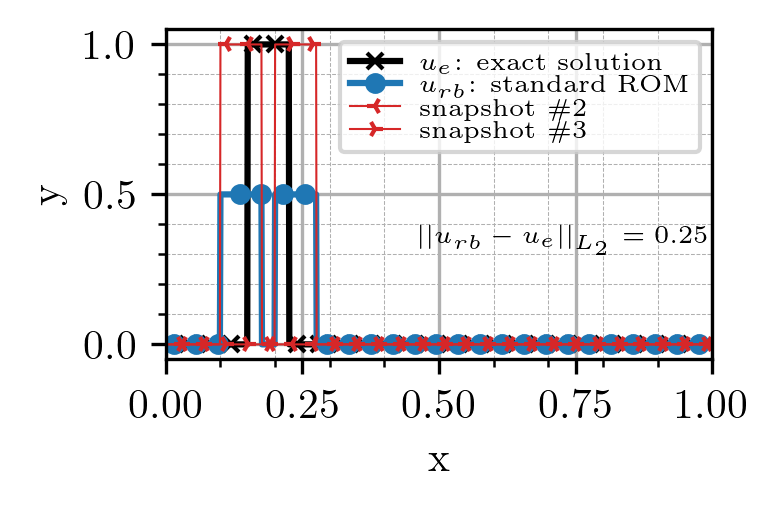

In [6]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, X_test[0], "kx-", ms=4, markevery=(0, markevery), label=r"$u_e$: exact solution")
plt.plot(x, X_test_ROM[0], "C0o-", ms=4, markevery=(15, markevery), label=r"$u_{rb}$: standard ROM")
plt.plot(x, X_train[1], "C3-3", ms=4, lw=.5, markevery=(30, markevery), label=r"snapshot \#2")
plt.plot(x, X_train[2], "C3-4", ms=4, lw=.5, markevery=(30, markevery), label=r"snapshot \#3")

ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend(loc="upper right")
#e = np.mean((bump(x, 0.35)-X_intp[:, 0])**2)**.5
ax.text(1, 0.35, r"$||u_{rb}-u_e||_{L_2}"+"={:.2f}$".format(e_ROM[0]), fontsize=6, horizontalalignment='right', verticalalignment='center')
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.savefig(pth+"standard_ROM.pdf")
plt.show()

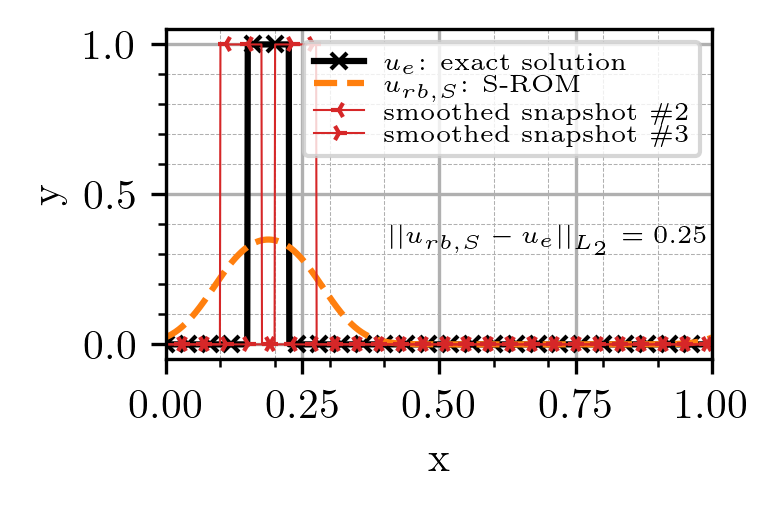

In [7]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, X_test[0], "kx-", ms=4, markevery=(0, markevery), label=r"$u_e$: exact solution")
plt.plot(x, X_test_sROM[0], "C1--", ms=4, markevery=(15, markevery), label=r"$u_{rb, S}$: S-ROM")
plt.plot(x, X_train[1], "C3-3", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#2")
plt.plot(x, X_train[2], "C3-4", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#3")

ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend(loc="upper right")
ax.text(1, 0.35, r"$||u_{rb,S}-u_e||_{L_2}"+"={:.2f}$".format(e_ROM[0]), fontsize=6, horizontalalignment='right', verticalalignment='center')
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.savefig(pth+"convolution_ROM.pdf")
plt.show()

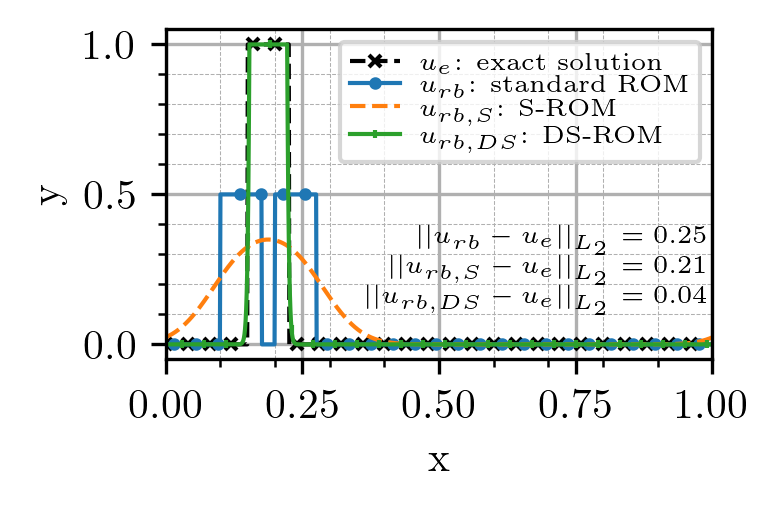

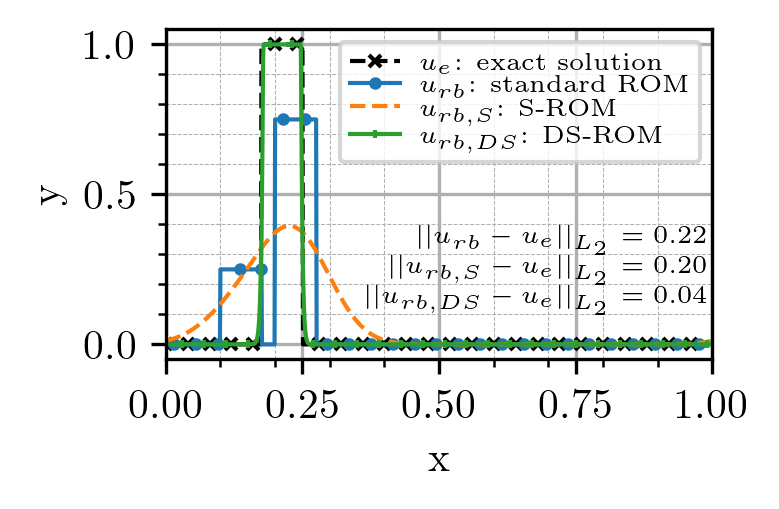

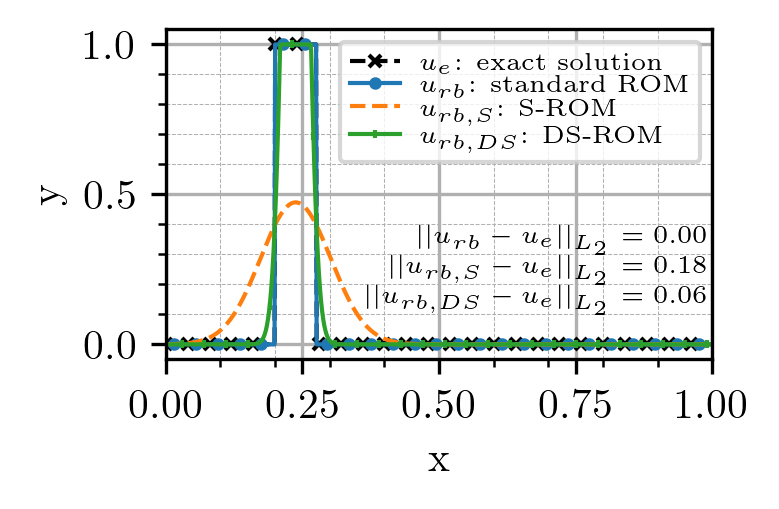

In [8]:
for ss in [0, 1, 2]:
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    ax.plot(x, X_test[ss, :], "kx--", ms=3, lw=1, markevery=(0, markevery), label=r"$u_e$: exact solution")
    ax.plot(x, X_test_ROM[ss, :], "C0o-", ms=2, lw=1, markevery=(15, markevery), label=r"$u_{rb}$: standard ROM")
    ax.plot(x, X_test_sROM[ss, :], "C1--", ms=2, lw=1, label=r"$u_{rb, S}$: S-ROM")
    ax.plot(x, X_test_sROMs[ss, :], "C2|-", ms=2, lw=1, markevery=(30, markevery), label=r"$u_{rb, DS}$: DS-ROM")
    # plt.plot(x, X_test[0], "kx-", ms=4, markevery=(0, markevery), label=r"$u_e$: exact solution")
    # plt.plot(x, X_test_sROM[0], "C1--", ms=4, markevery=(15, markevery), label=r"$u_{rb, S}$: S-ROM")
    # plt.plot(x, X_train[1], "C3-3", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#2")
    # plt.plot(x, X_train[2], "C3-4", ms=4, lw=.5, markevery=(30, markevery), label=r"smoothed snapshot \#3")
    
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend(loc="upper right")
    ax.text(0.999, 0.35, r"$||u_{rb}-u_e||_{L_2}"+"={:.2f}$".format(e_ROM[ss]), fontsize=6, horizontalalignment='right', verticalalignment='center')
    ax.text(0.999, 0.25, r"$||u_{rb, S}-u_e||_{L_2}"+"={:.2f}$".format(e_sROM[ss]), fontsize=6, horizontalalignment='right', verticalalignment='center')
    ax.text(0.999, 0.15, r"$||u_{rb, DS}-u_e||_{L_2}"+"={:.2f}$".format(e_sROMs[ss]), fontsize=6, horizontalalignment='right', verticalalignment='center')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, 1)
    plt.savefig(pth+"comparison_approaches{:.0f}.pdf".format(ss+1))
    plt.show()

In [9]:
case["n_test"] = 25
n_val = 500

10
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.05050000, 1.00000000, 0.19080839, 0.19117727, 0.08791342, -53.9258
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.08350000, 1.00000000, 0.19080839, 0.21489197, 0.05569941, -70.8087
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.01750000, 1.00000000, 0.19080839, 0.17293273, 0.20829452, 9.1642
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.05050000, 1.66666667, 0.19080839, 0.19117727, 0.04962450, -73.9925
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.05050000, 0.33333333, 0.19080839, 0.19117727, 0.17337893, -9.1345
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.08350000, 1.66666667, 0

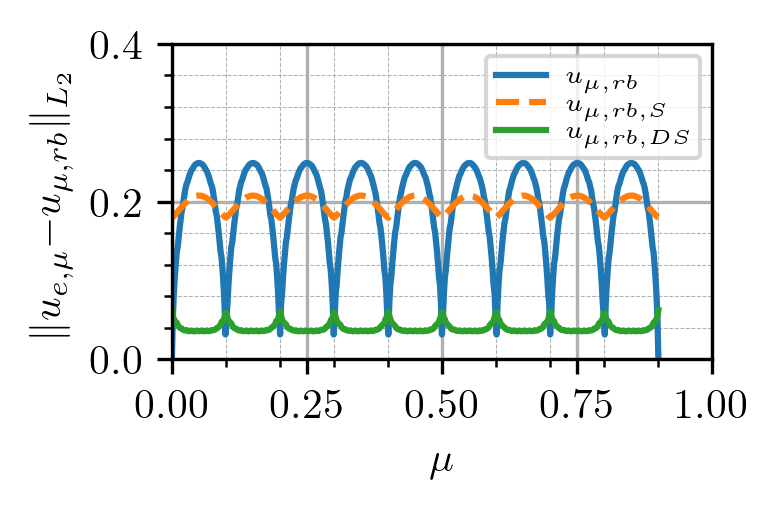

mean ROM: 0.056110
mean esROM: 0.179627 (-220.1359%)
mean esROMs: 0.035582 (36.5853%)
double check:
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.05783333, 1.98765432, 0.05500465, 0.17972839, 0.03688366, -32.9445
mean ROM: 0.055005
mean esROM: 0.179728 (-220.1359%)
mean esROMs: 0.036884 (36.5853%)


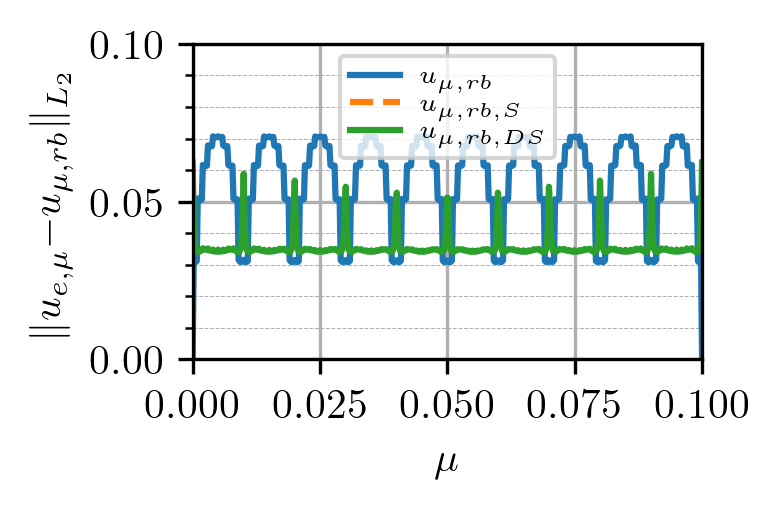

100
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00550000, 1.00000000, 0.05500465, 0.05708041, 0.02171225, -60.5265
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00850000, 1.00000000, 0.05500465, 0.06656768, 0.02666858, -51.5158
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00250000, 1.00000000, 0.05500465, 0.04981903, 0.06191575, 12.5646
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00550000, 1.66666667, 0.05500465, 0.05708041, 0.02263063, -58.8569
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00550000, 0.33333333, 0.05500465, 0.05708041, 0.04215783, -23.3559
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00850000, 1.66

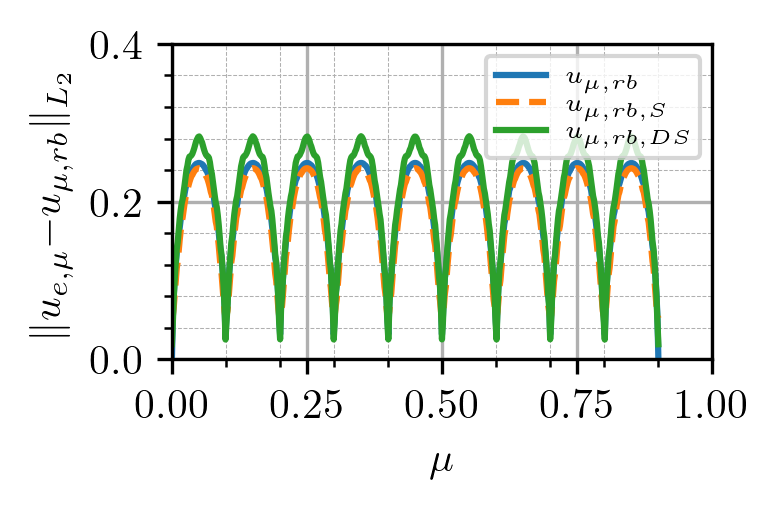

mean ROM: 0.056110
mean esROM: 0.058209 (-3.7409%)
mean esROMs: 0.019249 (65.6948%)
double check:
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00583333, 1.14814815, 0.05500465, 0.05812236, 0.01917566, -65.1381
mean ROM: 0.055005
mean esROM: 0.058122 (-3.7409%)
mean esROMs: 0.019176 (65.6948%)


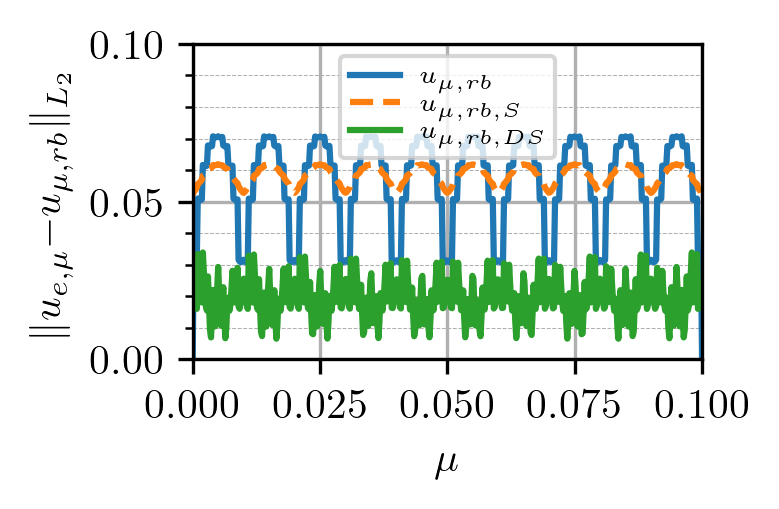

In [10]:
for i, rank in enumerate([10, 100]):
    n_train = rank
    print(rank)
    case["rank"] = rank
    case["n_train"] = n_train
    if rank == 10:
        parameters = np.array([0.05783333, 1.88888889])  # 0.03461111, 5.12345679  # 0.046817495544034825, 3.4777597632478527
    elif rank == 100:
        parameters = np.array([0.00583333, 1.14814815])  # 0.00627778, 0.55555556

    parameters = optimize_hyperparameters(case)
    case["sigma"], case["c"] = parameters[0], parameters[1]
    for rank, ylim in zip([10, 100], (0.4, 0.1)):
        n_train = rank
        case["rank"] = rank
        case["n_train"] = n_train
        mu_train, X_train, X_train_s = make_training_data(case)
        mu_val = np.linspace(mu_train[0], mu_train[min(len(mu_train)-1, 10)], n_val)
        X_val, X_val_s = get_data_rw(mu_val, **case)
    
        my_ROM = train_ROM_rw(mu_train, X_train)
        my_sROM = train_ROM_rw(mu_train, X_train_s)
    
        X_val_ROM = my_ROM.predict(mu_val).snapshots_matrix
        X_val_sROM, X_val_sROMs = get_predictions(my_sROM, mu_val, **case)

        mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
            X_val, X_val_ROM, X_val_sROM, X_val_sROMs
        )
        
    
        eROM = L2_error_rw(X_val_ROM, X_val)
        esROM = L2_error_rw(X_val_sROM, X_val)
        esROMs = L2_error_rw(X_val_sROMs, X_val)
        imp1 = 100 - np.mean(esROM) / np.mean(eROM) * 100
        imp2 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
        print("mean ROM: {:.6f}".format(np.mean(eROM)))
        print("mean esROM: {:.6f} ({:.4f}%)".format(np.mean(esROM), imp1))
        print("mean esROMs: {:.6f} ({:.4f}%)".format(np.mean(esROMs), imp2))

        print("double check:")
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        print("mean ROM: {:.6f}".format(mean_ROM))
        print("mean esROM: {:.6f} ({:.4f}%)".format(mean_sROM, imp1))
        print("mean esROMs: {:.6f} ({:.4f}%)".format(mean_sROMs, imp2))
    
        fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
        ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
        ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
        ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, DS}$")
        plt.ylabel(r"$\|u_{e,\mu}{-u_{\mu, rb}}\|_{L_2}$")
        plt.xlabel(r"$\mu$")
        plt.legend()
        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, ylim, 11, endpoint=True), minor=True)
        plt.grid(True, which="minor", linestyle="--", lw=0.25)
        plt.grid(True, which="major", linestyle="-")
        plt.xlim(0, 1)


        if len(mu_train) > 10:
            ax.set_xlim(mu_train[0], mu_train[10])
        ax.set_ylim(0, ylim)
        plt.savefig(pth+"S{:.0f}R{:.0f}.pdf".format(i+1, rank))
        plt.show()
    
